In [1]:
from LC_utility import *
from pdastro import *

In [2]:
plt.rcParams['axes.labelsize'] =  26     # size of x/y labels
plt.rcParams['xtick.labelsize'] = 18   # size of tick labels
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['legend.fontsize'] = 24

### load data

In [3]:
### Read in Models
#lcpath = './data/'
lcpath = '../python_fitting/LC_tables/models/'

# before gaussian processing
#LCm2_i = pd.read_csv(lcpath +'M2_iEtaCarLC.csv')
#LCm2_g = pd.read_csv(lcpath +'M2_gEtaCarLC.csv')
#LCm2_r = pd.read_csv(lcpath +'M2_rEtaCarLC.csv')
#LCm2_z = pd.read_csv(lcpath +'M2_zEtaCarLC.csv')

# new model using gaussian processing
LCm2_i = pd.read_csv(lcpath +'iLC_m2.csv')
LCm2_g = pd.read_csv(lcpath +'gLC_m2.csv')
LCm2_r = pd.read_csv(lcpath +'rLC_m2.csv')
LCm2_z = pd.read_csv(lcpath +'zLC_m2.csv')

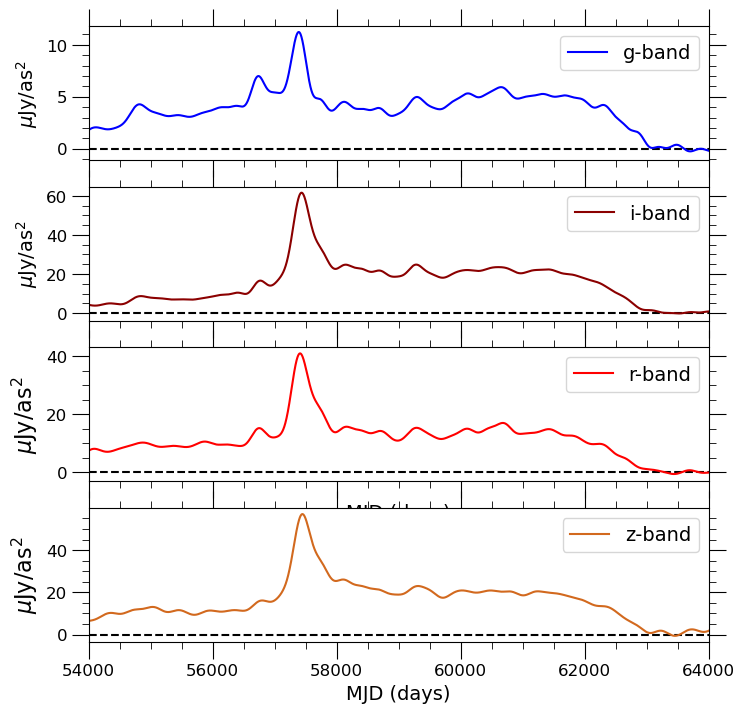

In [4]:
fig, axs = plt.subplots(4,1,dpi = 100, figsize = [8,8], sharex=True)
axs = axs.flatten() 

axs[0].minorticks_on()
axs[0].tick_params(axis='x', labelsize=12)
axs[0].tick_params(axis='y', labelsize=12)
axs[0].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[0].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
# axs[0].gca().set_xlabel('mjd', fontsize = 14)
axs[0].set_ylabel(r'$\mu$Jy/as$^2$', fontsize = 14)
axs[0].ticklabel_format(axis='both', style='plain')

axs[0].errorbar(LCm2_g['mjd'], LCm2_g['muJyas2'], fmt='-', ecolor='black', color='blue', label='g-band')
axs[0].axhline(y=0, linestyle='--', color='black')
axs[0].set_xlim(54000, 64000)
axs[0].legend(fontsize = 14)


axs[1].minorticks_on()
axs[1].tick_params(axis='x', labelsize=12)
axs[1].tick_params(axis='y', labelsize=12)
axs[1].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[1].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
axs[1].set_ylabel(r'$\mu$Jy/as$^2$', fontsize = 14)
axs[1].ticklabel_format(axis='both', style='plain')

axs[1].errorbar(LCm2_i['mjd'], LCm2_i['muJyas2'], fmt='-', ecolor='black', color='darkred', label='i-band')
axs[1].axhline(y=0, linestyle='--', color='black')
axs[1].set_xlim(54000, 64000)
axs[1].legend(fontsize = 14)


axs[2].minorticks_on()
axs[2].tick_params(axis='x', labelsize=12)
axs[2].tick_params(axis='y', labelsize=12)
axs[2].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[2].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
axs[2].set_xlabel('MJD (days)', fontsize = 14)
axs[2].set_ylabel(r'$\mu$Jy/as$^2$', fontsize = 16)
axs[2].ticklabel_format(axis='both', style='plain')

axs[2].errorbar(LCm2_r['mjd'], LCm2_r['muJyas2'], fmt='-', ecolor='black', color='red', label='r-band')
axs[2].axhline(y=0, linestyle='--', color='black')
axs[2].set_xlim(54000, 64000)
axs[2].legend(fontsize = 14)


axs[3].minorticks_on()
axs[3].tick_params(axis='x', labelsize=12)
axs[3].tick_params(axis='y', labelsize=12)
axs[3].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[3].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
axs[3].set_xlabel('MJD (days)', fontsize = 14)
axs[3].set_ylabel(r'$\mu$Jy/as$^2$', fontsize = 16)
axs[3].ticklabel_format(axis='both', style='plain')

axs[3].errorbar(LCm2_z['mjd'], LCm2_z['muJyas2'], fmt='-', ecolor='black', color='chocolate', label='z-band')
axs[3].axhline(y=0, linestyle='--', color='black')
axs[3].set_xlim(54000, 64000)
axs[3].legend(fontsize = 14)

### convert to AB mag

In [5]:
working_inds_i = np.where(LCm2_i['muJyas2']>0.)[0]
working_inds_g = np.where(LCm2_g['muJyas2']>0.)[0]
working_inds_r = np.where(LCm2_r['muJyas2']>0.)[0]
working_inds_z = np.where(LCm2_z['muJyas2']>0.)[0]

mag_i, mag_err_i = convert_Jy2mag(LCm2_i.loc[working_inds_i,'muJyas2'].values, LCm2_i.loc[working_inds_i,'muJyas2_err'].values)
mag_g, mag_err_g = convert_Jy2mag(LCm2_g.loc[working_inds_g,'muJyas2'].values, LCm2_g.loc[working_inds_g,'muJyas2_err'].values)
mag_r, mag_err_r = convert_Jy2mag(LCm2_r.loc[working_inds_r,'muJyas2'].values, LCm2_r.loc[working_inds_r,'muJyas2_err'].values)
mag_z, mag_err_z = convert_Jy2mag(LCm2_z.loc[working_inds_z,'muJyas2'].values, LCm2_z.loc[working_inds_z,'muJyas2_err'].values)

LCm2_i.loc[working_inds_i,'AB_mag'] = np.array(mag_i)
LCm2_i.loc[working_inds_i,'AB_mag_err'] = np.array(mag_err_i)
LCm2_g.loc[working_inds_g,'AB_mag'] = np.array(mag_g)
LCm2_g.loc[working_inds_g,'AB_mag_err'] = np.array(mag_err_g)
LCm2_r.loc[working_inds_r,'AB_mag'] = np.array(mag_r)
LCm2_r.loc[working_inds_r,'AB_mag_err'] = np.array(mag_err_r)
LCm2_z.loc[working_inds_z,'AB_mag'] = np.array(mag_z)
LCm2_z.loc[working_inds_z,'AB_mag_err'] = np.array(mag_err_z)

In [6]:
#t_ran = np.arange(54000, 63500)
t_ran = np.arange(54000, 62800)

i_new = splev(t_ran, splrep(LCm2_i.loc[working_inds_i,'mjd'], LCm2_i.loc[working_inds_i,'AB_mag'], k=1))
i_new_err = splev(t_ran, splrep(LCm2_i.loc[working_inds_i,'mjd'], LCm2_i.loc[working_inds_i,'AB_mag_err'], k=1))
g_new = splev(t_ran, splrep(LCm2_g.loc[working_inds_g,'mjd'], LCm2_g.loc[working_inds_g,'AB_mag'], k=1))
g_new_err = splev(t_ran, splrep(LCm2_g.loc[working_inds_g,'mjd'], LCm2_g.loc[working_inds_g,'AB_mag_err'], k=1))

r_new = splev(t_ran, splrep(LCm2_r.loc[working_inds_r,'mjd'], LCm2_r.loc[working_inds_r,'AB_mag'], k=1))
r_new_err = splev(t_ran, splrep(LCm2_r.loc[working_inds_r,'mjd'], LCm2_r.loc[working_inds_r,'AB_mag_err'], k=1))


z_new = splev(t_ran, splrep(LCm2_z.loc[working_inds_z,'mjd'], LCm2_z.loc[working_inds_z,'AB_mag'], k=1))

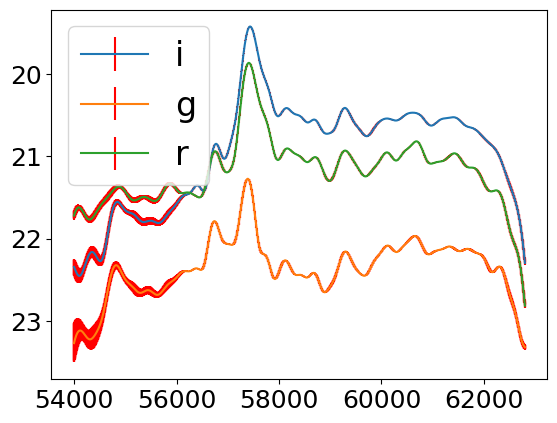

In [7]:
plt.errorbar(t_ran, i_new, i_new_err, ecolor='r', label='i')
plt.errorbar(t_ran, g_new, g_new_err, ecolor='r', label='g')
plt.errorbar(t_ran, r_new, r_new_err, ecolor='r', label='r')

plt.gca().invert_yaxis()
plt.legend()

Text(0, 0.5, 'color')

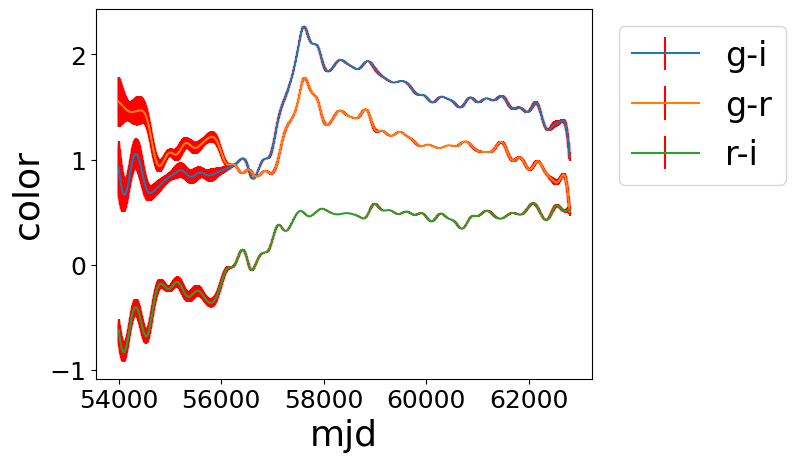

In [37]:
g_i = g_new - i_new
g_i_err = np.sqrt(g_new_err**2 + i_new_err**2)
plt.errorbar(t_ran, g_i, g_i_err, ecolor='r', label='g-i')


g_r = g_new - r_new
g_r_err = np.sqrt(g_new_err**2 + r_new_err**2,)

plt.errorbar(t_ran, g_r, g_r_err, ecolor='r', label='g-r')


r_i = r_new - i_new
r_i_err = np.sqrt(r_new_err**2 + i_new_err**2)
plt.errorbar(t_ran, r_i, r_i_err, ecolor='r', label='r-i')

#plt.gca().invert_yaxis()
plt.legend(bbox_to_anchor=(1.02, 1))

#plt.ylim([0.5, 2.9])

plt.xlabel('mjd')
plt.ylabel('color')

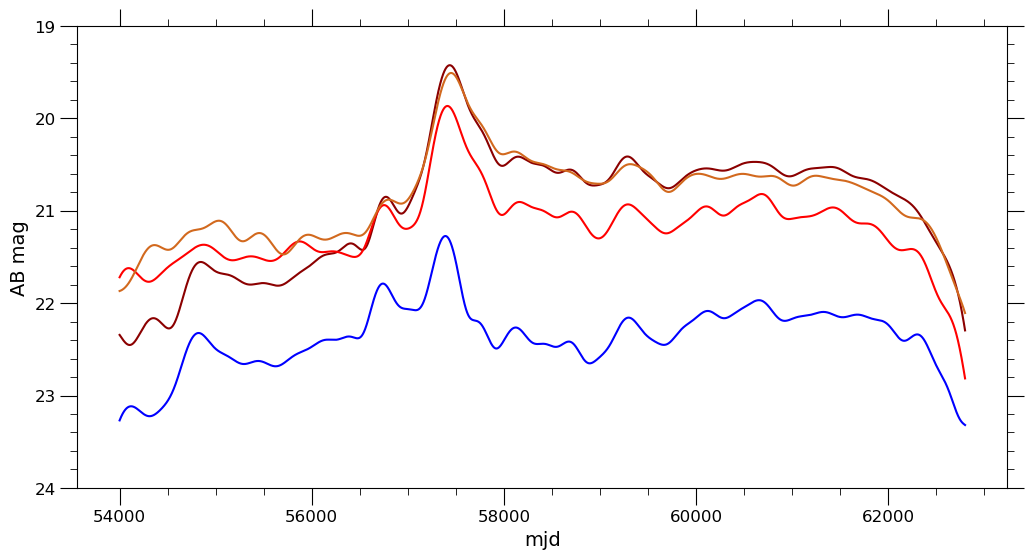

In [9]:
plt.subplots(dpi = 100, figsize = [12,6])
plt.minorticks_on()
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12)
plt.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
plt.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
plt.gca().set_xlabel('mjd', fontsize = 14)
plt.gca().set_ylabel('AB mag', fontsize = 14)
plt.ticklabel_format(axis='both', style='plain')

plt.errorbar(t_ran, g_new, ecolor='black', color='blue')
plt.errorbar(t_ran, i_new, ecolor='black', color='darkred')
plt.errorbar(t_ran, r_new, ecolor='black', color='red')
plt.errorbar(t_ran, z_new, ecolor='black', color='chocolate')

plt.ylim(19,24)
plt.gca().invert_yaxis()

# plt.axvline(54850, color='k', ls='--')
# plt.axvline(56740, color='k', ls='--')
# plt.axvline(57430, color='k', ls='--')
# plt.axvline(59300, color='k', ls='--')

### estimate temperature

- convert SDSS griz to VRI

- estimate color temperature use relations from emperical calibration


#### V-I to Teff

In [10]:
# data from Table 5, A. Alonso et al.: Empirical calibration of Teff versus colours and [Fe/H].

t_effs = np.array([3500,3750,4000,4250,4500,4750,5000,5250,5500,5750,6000,6250,6500,6750,7000,7250,7500,7750,8000 ])

V_Is = np.array([2.800,2.210,1.865,1.625,1.435,1.275,1.135,1.015,0.910,0.815,0.725,0.645,0.575,0.505,0.440,0.380,0.325,0.275,0.225])


Theta = 5040 / t_effs



In [11]:
np.polyfit(V_Is, Theta, deg=3)

array([-0.0192951 ,  0.0197577 ,  0.41923694,  0.53356974])

In [12]:
# V-I to T_eff

def VI_to_Teff(VI):
    """
    Convert (V-I) color to Teff [K] = 5040 / Theta.

    Theta = a0 + a1(V-I) + a2 (V-I)**2 + a3 (V-I)**3
    
    Reference: A. Alonso et al.: Empirical calibration of Teff versus colours and [Fe/H].
    """
    VI = np.asarray(VI)

    # value from np.polyfit
    a3, a2, a1, a0 = -0.0192951 ,  0.0197577 ,  0.41923694,  0.53356974
    
    Theta = a0 + a1 * VI + a2 * VI ** 2 + a3 * VI ** 3
    
    return 5040 / Theta


Text(0, 0.5, 'T eff')

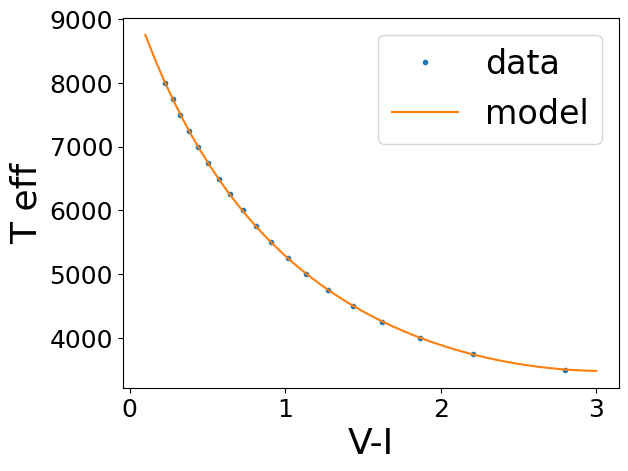

In [13]:
# test fitting

V_I_test = np.linspace(0.1, 3)

Teff_VI_test = VI_to_Teff(V_I_test)

plt.plot(V_Is, t_effs, '.', label='data')
plt.plot(V_I_test, Teff_VI_test, label='model')
plt.legend()
plt.xlabel('V-I')
plt.ylabel('T eff')

#### V-R to Teff

In [14]:
t_effs = np.array([3750,  4000,  4250,  4500,  4750,  5000,  5250, 5500,  5750,  6000, 6250, 6500, 6750, 7000,  7250, 7500, 7750, 8000])

V_Rs = np.array([1.350, 1.145, 0.990, 0.865, 0.760, 0.680, 0.6, 0.535, 0.480, 0.425, 0.380, 0.340, 0.300, 0.265, 0.235, 0.205, 0.180, 0.155])

Theta = 5040 / t_effs


In [15]:
np.polyfit(V_Rs, Theta, deg=3)

array([-2.28030203e-04, -1.88669354e-01,  8.81425556e-01,  4.98517999e-01])

In [16]:
# V-R to T_eff

def VR_to_Teff(VR):
    """
    Convert (V-I) color to Teff [K] = 5040 / Theta.

    Theta = a0 + a1(V-I) + a2 (V-I)**2 + a3 (V-I)**3
    
    Reference: A. Alonso et al.: Empirical calibration of Teff versus colours and [Fe/H].
    """
    VR = np.asarray(VR)

    # value from np.polyfit
    a3, a2, a1, a0 = -2.28030203e-04, -1.88669354e-01,  8.81425556e-01,  4.98517999e-01
    
    Theta = a0 + a1 * VR + a2 * VR ** 2 + a3 * VR ** 3
    
    return 5040 / Theta


Text(0, 0.5, 'T eff')

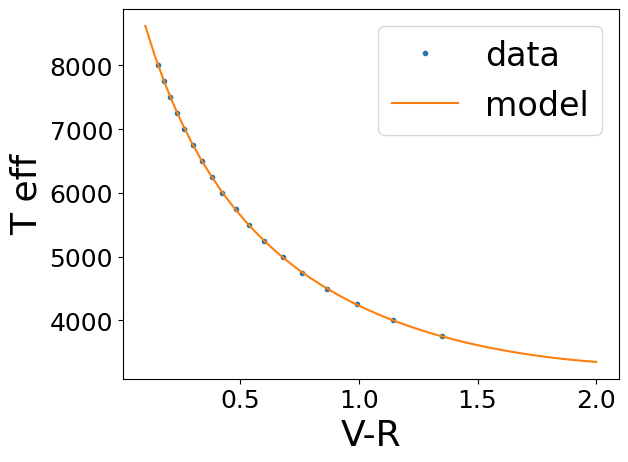

In [17]:
# test fitting

V_R_test = np.linspace(0.1, 2)

Teff_VR_test = VR_to_Teff(V_R_test)

plt.plot(V_Rs, t_effs, '.', label='data')
plt.plot(V_R_test, Teff_VR_test, label='model')
plt.legend()
plt.xlabel('V-R')
plt.ylabel('T eff')



#### R-I to Teff

In [18]:
t_effs = np.array([3750,  4000,  4250,  4500,  4750,  5000,  5250, 5500,  5750,  6000, 6250, 6500, 6750, 7000,  7250, 7500, 7750, 8000])

R_Is = np.array([1.005, 0.815, 0.690, 0.595, 0.520, 0.460, 0.405,0.360, 0.320, 0.285,0.255,0.225,0.2, 0.175, 0.155, 0.135, 0.120, 0.100])

Theta = 5040 / t_effs


In [19]:
np.polyfit(R_Is, np.log10(t_effs), deg=2)

array([ 0.36852784, -0.75623926,  3.96836573])

In [20]:
np.polyfit(R_Is, Theta, deg=3)

array([-0.00372186, -0.48393689,  1.32916366,  0.50060817])

In [21]:
def RI_to_Teff(RI, model='poly'):
    """
    """
    RI = np.asarray(RI)

    # value from np.polyfit
    if model=='poly':
        # only works for RI<1
        a3, a2, a1, a0 = -0.00372186, -0.48393689,  1.32916366,  0.50060817
    
        Theta = a0 + a1 * RI + a2 * RI ** 2 + a3 * RI ** 3

        return 5040 / Theta
    
    if model=='exp':
        a3, a2, a1, a0 = -0.2610645,  0.78625533, -0.93975579,  3.98867204
        #a3, a2, a1, a0 = 0, 0.36852784, -0.75623926,  3.96836573
        logTeff = a0 + a1 * RI + a2 * RI ** 2 + a3 * RI ** 3
    
        return 10 ** logTeff


Text(0, 0.5, 'T eff')

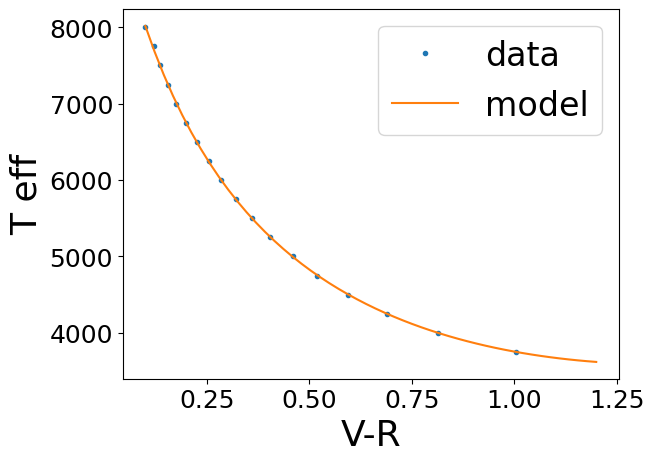

In [22]:
# test fitting

R_I_test = np.linspace(0.1, 1.2)

Teff_RI_test = RI_to_Teff(R_I_test, model='poly')

plt.plot(R_Is, t_effs, '.', label='data')
plt.plot(R_I_test, Teff_RI_test, label='model')
plt.legend()
plt.xlabel('V-R')
plt.ylabel('T eff')


Text(0, 0.5, 'T eff')

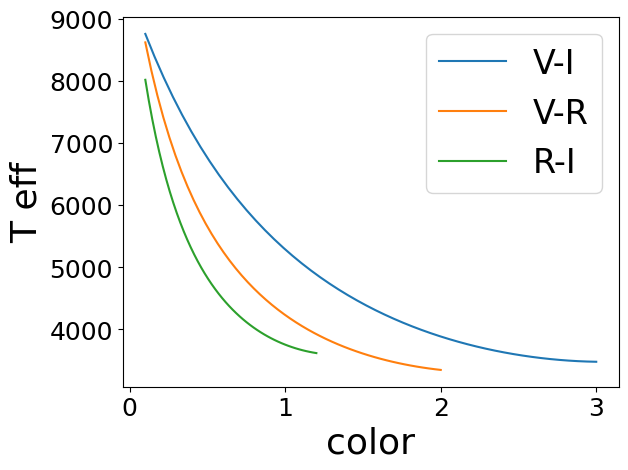

In [23]:
# test fitting
plt.plot(V_I_test, Teff_VI_test, label='V-I')

plt.plot(V_R_test, Teff_VR_test, label='V-R')

plt.plot(R_I_test, Teff_RI_test, label='R-I')

plt.legend()
plt.xlabel('color')
plt.ylabel('T eff')



### griz to VRI

https://www.sdss3.org/dr8/algorithms/sdssUBVRITransform.php#Jordi2006

Jordi et al. (2005)


In [24]:
def gi_to_VI(gi):
    """
    Convert g-i to V-I, from
    https://www.sdss3.org/dr8/algorithms/sdssUBVRITransform.php#Jordi2006
    """
    VI = (0.675)*(gi)  + (0.364)
    return VI

def gr_to_VR(gr):
    """
    Convert g-r to V-R, from
    https://www.sdss3.org/dr8/algorithms/sdssUBVRITransform.php#Jordi2006
    """
    VR = 1/1.646 * gr + 0.139 / 1.646
    return VR

def ri_to_RI(ri):
    """
    Convert ri to R-I, from
    https://www.sdss3.org/dr8/algorithms/sdssUBVRITransform.php#Jordi2006
    """
    RI = (0.930)*ri + (0.259)
    
    return RI

def rz_to_RI(rz):
    RI = rz/1.584 + 0.386/1.584

    return RI

def iz_to_RI(iz):
    # convert iz to RI
    #iz = rz - ri
    RI = 1 / (1.584 - 1/0.930) * iz + (0.386 - 0.259/0.930) / (1.584 - 1/0.930)
    return RI


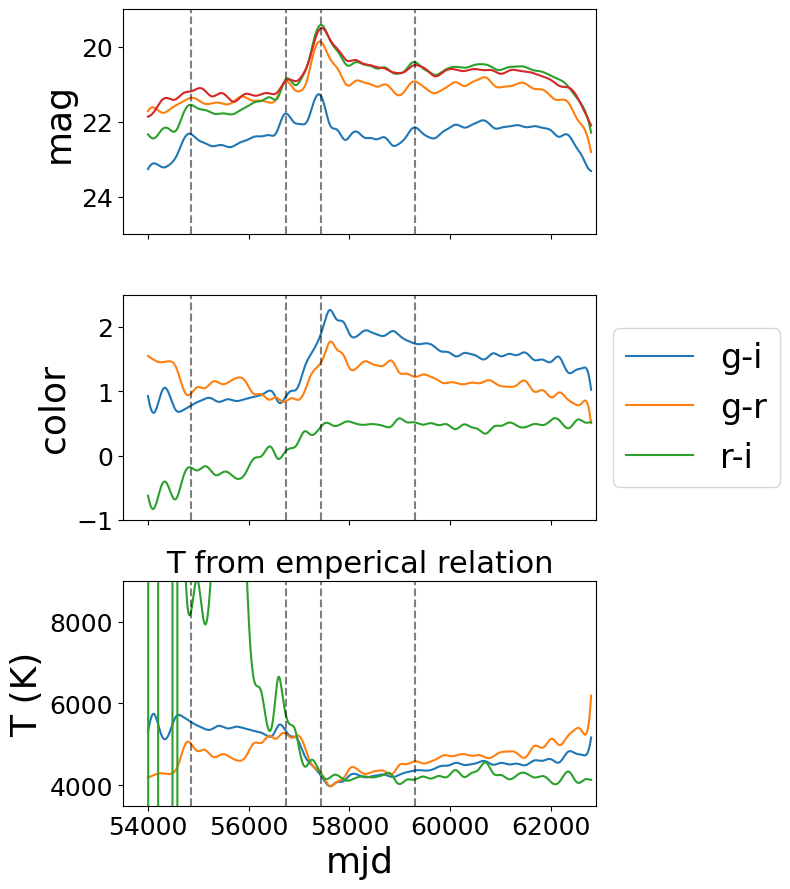

In [38]:
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(8, 9))

ax = axs[0]

ax.plot(t_ran, g_new)
ax.plot(t_ran, r_new)
ax.plot(t_ran, i_new)
ax.plot(t_ran, z_new)

ax.invert_yaxis()
ax.set_ylabel('mag')
ax.set_ylim([25, 19])

ax = axs[1]

color_gr = g_new - r_new
color_ri = r_new - i_new
color_iz = i_new - z_new
color_gi = g_new - i_new
color_rz = r_new - z_new

ax.plot(t_ran, color_gi, label='g-i')
ax.plot(t_ran, color_gr, label='g-r')
ax.plot(t_ran, color_ri, label='r-i')
#ax.plot(t_ran, color_iz, label='i-z')
#ax.plot(t_ran, color_rz, label='r-z')

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_ylabel('color')

ax.set_ylim([-1, 2.5])

ax = axs[2]
T_gr = VR_to_Teff( gr_to_VR(color_gr) )
T_ri = RI_to_Teff( ri_to_RI(color_ri) )
T_iz = RI_to_Teff( iz_to_RI(color_iz) )

T_gi = VI_to_Teff( gi_to_VI(color_gi) )
T_rz = RI_to_Teff( rz_to_RI(color_rz) )

ax.plot(t_ran, T_gi, label='g-i')
ax.plot(t_ran, T_gr, label='g-r')
ax.plot(t_ran, T_ri, label='r-i')
#ax.plot(t_ran, T_iz, label='i-z')
#ax.plot(t_ran, T_rz, label='r-z')

ax.set_ylim([3500, 9000])
ax.set_xlabel('mjd')
ax.set_ylabel('T (K)')
ax.set_title('T from emperical relation', fontsize=22)

for ax in axs:
    ax.axvline( 54850, color='k', ls='--', alpha=0.5)
    ax.axvline( 56740, color='k', ls='--', alpha=0.5)
    ax.axvline( 57430, color='k', ls='--', alpha=0.5)
    ax.axvline( 59300, color='k', ls='--', alpha=0.5)
    ax.set_xlim([53500, 57430 + 15*365])

fig.tight_layout()


### estimate from blackbody spectra

In [26]:
import numpy as np
from scipy.optimize import fsolve

# Constants
h = 6.626e-27       # erg*s
c = 2.998e18        # Å/s
k = 1.381e-16       # erg/K

# SDSS effective wavelengths in Angstrom
lambda_g = 4770
lambda_r = 6370
lambda_i = 7785
lambda_z = 9155

# observed color
g_i_obs = 1.0  # example

def color_eq(T, g_i_obs, lambda_1, lambda_2):
    # estimate temperature from lambda_1 - lambda_2
    # 
    
    B_ratio = (lambda_2**5 / lambda_1**5) * (
        (np.exp(h*c/(lambda_2*k*T)) - 1) / (np.exp(h*c/(lambda_1*k*T)) - 1)
    )
    return -2.5 * np.log10(B_ratio) - g_i_obs

T_eff = fsolve(color_eq, 6000, (g_i_obs, lambda_g, lambda_i))[0]
print("Effective temperature:", T_eff)



Effective temperature: 3470.079443689998


In [27]:
import numpy as np

# --- Physical constants in convenient units ---
h  = 6.62607015e-27       # erg·s
c  = 2.99792458e18        # Å/s
k  = 1.380649e-16         # erg/K

# --- SDSS effective wavelengths in Å ---
lambda_g = 4770.0
lambda_i = 7785

def B_lambda_angstrom(lam, T):
    """
    Planck function B_lambda in cgs with λ in Å.
    Returns arbitrary units (ratio is what matters).
    """
    x = h*c/(lam*k*T)
    return (2*h*c**2) / (lam**5 * (np.exp(x) - 1))

def gi_from_T(T):
    """Return g-i color for blackbody of temperature T (K)."""
    Bg = B_lambda_angstrom(lambda_g, T)
    Bi = B_lambda_angstrom(lambda_i, T)
    return -2.5 * np.log10(Bg / Bi)


/var/folders/yb/hm0wbr8128v_fbvy474l5s6m0000gn/T/ipykernel_29931/2422759602.py:23: RuntimeWarning: overflow encountered in exp
  (np.exp(h*c/(lambda_2*k*T)) - 1) / (np.exp(h*c/(lambda_1*k*T)) - 1)
/var/folders/yb/hm0wbr8128v_fbvy474l5s6m0000gn/T/ipykernel_29931/2422759602.py:25: RuntimeWarning: divide by zero encountered in log10
  return -2.5 * np.log10(B_ratio) - g_i_obs
/var/folders/yb/hm0wbr8128v_fbvy474l5s6m0000gn/T/ipykernel_29931/2422759602.py:23: RuntimeWarning: invalid value encountered in divide
  (np.exp(h*c/(lambda_2*k*T)) - 1) / (np.exp(h*c/(lambda_1*k*T)) - 1)
/var/folders/yb/hm0wbr8128v_fbvy474l5s6m0000gn/T/ipykernel_29931/71181187.py:26: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  T_eff = fsolve(color_eq, 4000, (i, lambda_i, lambda_z))[0]


Text(0.5, 1.0, 'T from blackbody')

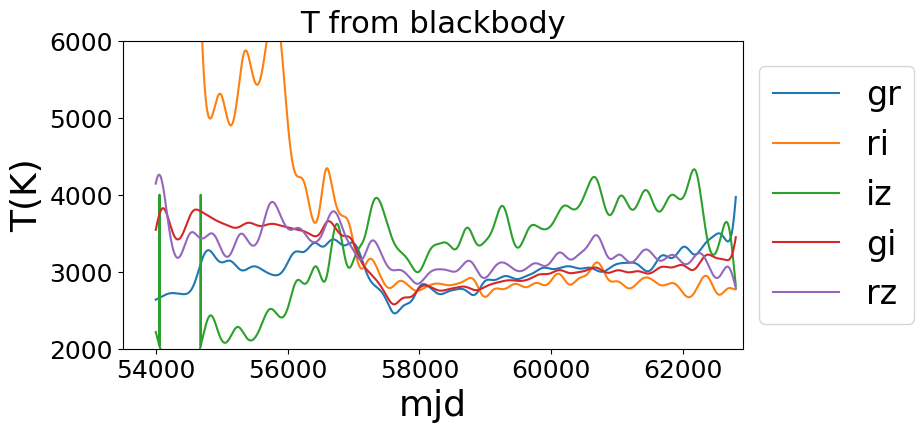

In [28]:

plt.figure(figsize=(8, 4))

teff = []
for i in color_gr:
    T_eff = fsolve(color_eq, 4000, (i, lambda_g, lambda_r))[0]
    teff.append(T_eff)

plt.plot(t_ran, teff, label='gr')

plt.ylim([2000, 6000])
#--------------

teff = []
for i in color_ri:
    T_eff = fsolve(color_eq, 4000, (i, lambda_r, lambda_i))[0]
    teff.append(T_eff)

plt.plot(t_ran, teff, label='ri')

plt.ylim([2000, 6000])


#----------------
teff = []
for i in color_iz:
    T_eff = fsolve(color_eq, 4000, (i, lambda_i, lambda_z))[0]
    teff.append(T_eff)

plt.plot(t_ran, teff, label='iz')

plt.ylim([2000, 6000])

#-----------------

teff = []
for i in color_gi:
    T_eff = fsolve(color_eq, 4000, (i, lambda_g, lambda_i))[0]
    teff.append(T_eff)

plt.plot(t_ran, teff, label='gi')


# -----------------------------
teff = []
for i in color_rz:
    T_eff = fsolve(color_eq, 4000, (i, lambda_r, lambda_z))[0]
    teff.append(T_eff)

plt.plot(t_ran, teff, label='rz')


# ---------------------
plt.xlim([53500, 57430 + 15*365])

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.xlabel('mjd')

plt.ylabel('T(K)')

plt.title('T from blackbody', fontsize=22)

### estimate radius

In [29]:
# Constants
R_sun = 6.957e10       # Solar radius in cm

T_sun = 5772           # Solar effective temperature in K
M_bol_sun = 4.74       # Solar bolometric magnitude

# Example bolometric correction function for i-band
def BC_i(T_eff):
    # assume linear and small
    #bc_i = 0.1 - 0.0001 * (T_eff - 5772)
    #return bc_i
    
    return 0

def radius_from_Mi_Teff(M_i, T_eff):
    """
    Compute stellar radius in solar radii from i-band magnitude and effective temperature.
    
    Parameters
    ----------
    M_i : float
        Absolute magnitude in i-band
    T_eff : float
        Effective temperature in Kelvin
    
    Returns
    -------
    R : float
        Stellar radius in solar radii
    """
    BC = BC_i(T_eff)
    log_R_Rsun = (M_bol_sun - M_i - BC)/5 - 2*np.log10(T_eff/T_sun)
    R = 10**log_R_Rsun
    
    return R


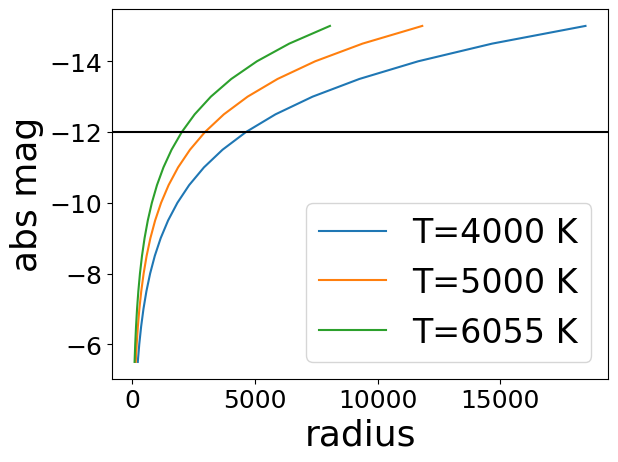

In [30]:
# radius, mag, temperature ralation

mags = np.arange(-15, -5, .5)

for ti in [4000, 5000, 6055]:
    r = radius_from_Mi_Teff(mags, ti,)

    plt.plot(r, mags, label=f'T={ti} K')

#plt.axvline(x=240, c='k')
plt.axhline(y=-12, c='k')
plt.xlabel('radius')
plt.ylabel('abs mag')
plt.gca().invert_yaxis()

plt.legend()


filter transformation

https://astroweb.case.edu/ssm/ASTR620/mags.html#conversions 

Windhorst, R. W., et al. 1991, ApJ, 380, 362 


In [31]:

V_new = g_new - 0.03 - 0.42*(g_new - r_new)


In [32]:
# 3rd peak 

# match absolute magnitude 
V_new.min() + 12 # apparent magnitude from historical record ~ -12


np.float64(32.65516370813283)

In [33]:
color_gi = g_new - i_new

T = VI_to_Teff( gi_to_VI(color_gi) )

R_ec = radius_from_Mi_Teff(g_new - 32.65, T)


Text(0, 0.5, '')

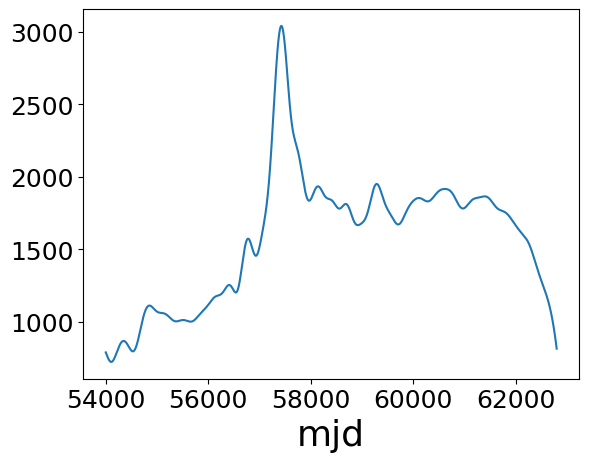

In [34]:
plt.plot(t_ran, R_ec)

plt.xlabel('mjd')
plt.ylabel('')

## HR diagram

(0.2, 2.35)

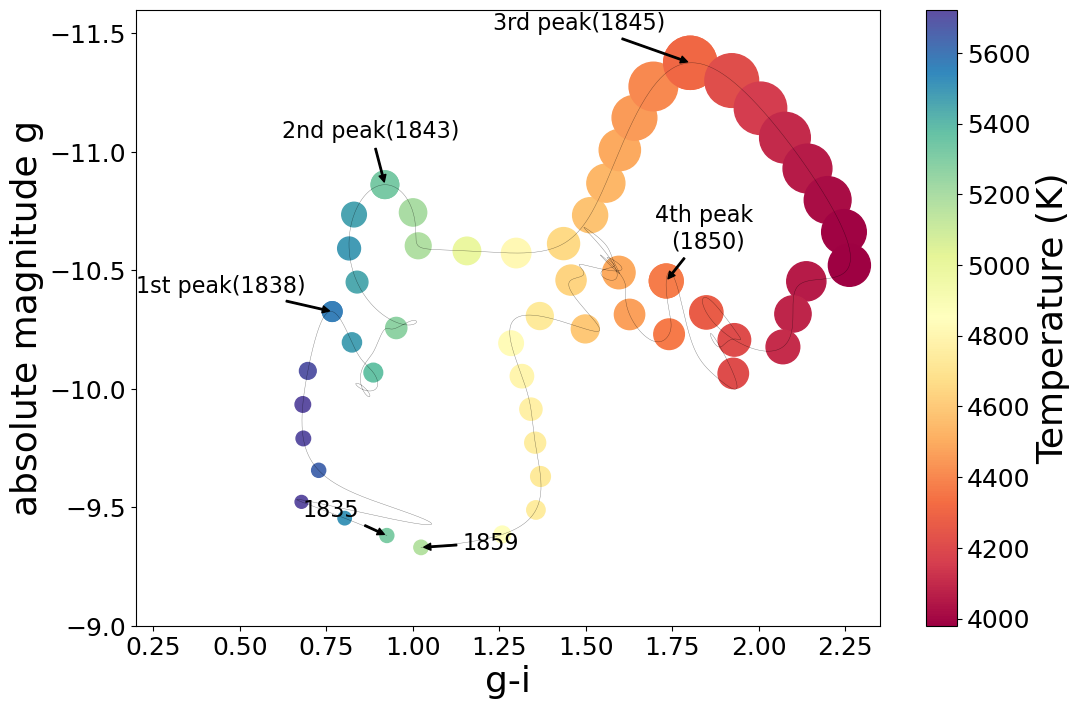

In [35]:
plt.figure(figsize=(12, 8))
#idx = t_ran < 64000

idx = t_ran < 62900

step = 1

color_gi = g_new[idx][::step] - i_new[idx][::step]

#color_gi = g_new[idx][::step] - z_new[idx][::step]

mag_i = g_new[idx][::step] 
abs_mag_i = mag_i-32.65

t = t_ran[idx][::step]

T = VI_to_Teff( gi_to_VI(color_gi) )

R_ec_bk = radius_from_Mi_Teff(abs_mag_i, T)

R_ec = R_ec_bk**2 / 615.132 /2

# plot the line
plt.plot(color_gi, abs_mag_i, '-', alpha=.5, c='k', lw=.3)

#plt.scatter(color_gi, abs_mag_i, s=1, c=T, cmap=plt.cm.Spectral)


#plt.scatter( T, abs_mag_i , alpha=0.4, s=R_ec/5, edgecolors='black',
#            c=t, cmap=plt.cm.Purples, )

color_gi_show = [color_gi[0], color_gi[-1]]
m_show = [abs_mag_i[0], abs_mag_i[-1]]
T_show = [T[0], T[-1]]
R_show = [R_ec[0], R_ec[-1]]

#values = np.array(t)
values = np.array(T)

# Normalize the array to range [0, 1] for the colormap
norm = (values - values.min()) / (values.max() - values.min())

# Get colors from the Purples colormap
#colors = plt.cm.Purples(0.5+0.5*norm)

colors = plt.cm.Spectral(norm)
#colors = plt.cm.RdBu(norm)
#---------------------------------------------------
# plot the first dot

x_first = color_gi[0]
y_first = abs_mag_i[0]

#plt.scatter(x_first, y_first, s=R_ec[0]/5, color=colors[0]);

plt.annotate('1835', fontsize=16,
            xy=(x_first, y_first), xycoords='data',
            xytext=(-40, 10), textcoords='offset points',
            arrowprops=dict(facecolor='black', arrowstyle='simple, head_length=1, head_width=1', mutation_scale=5),
            horizontalalignment='center', verticalalignment='bottom')

#------------------
# plot peaks
mjd_peak1 = 54890 - 60
idx_peak1 = np.argmin(np.abs(t_ran[::step] - mjd_peak1))

x_peak1 = color_gi[idx_peak1]
y_peak1 = abs_mag_i[idx_peak1]


#plt.text(x_peak1+600, y_peak1-0.1, '1st peak(1838)', c='k', fontsize=16)
#plt.arrow(x_peak1, y_peak1, 0, -0.1, head_width=0.05, head_length=0.05,)

#plt.scatter(x_peak1, y_peak1, s=R_ec[idx_peak1]/5, color=colors[idx_peak1])

color_gi_show.append(x_peak1)
m_show.append(y_peak1)
T_show.append(T[idx_peak1])
R_show.append(R_ec[idx_peak1])

plt.annotate('1st peak(1838)', fontsize=16,
            xy=(x_peak1, y_peak1), xycoords='data',
            xytext=(-80, 10), textcoords='offset points',
            arrowprops=dict(facecolor='black', arrowstyle='simple, head_length=1, head_width=1', mutation_scale=5),
            horizontalalignment='center', verticalalignment='bottom')

#---------------------

mjd_peak1 = 56690 + 50
idx_peak1 = np.argmin(np.abs(t_ran[::step] - mjd_peak1))
x_peak1 = color_gi[idx_peak1]
y_peak1 = abs_mag_i[idx_peak1]
#plt.scatter(x_peak1, y_peak1, s=R_ec[idx_peak1]/5, color=colors[idx_peak1])

#plt.text(x_peak1+200, y_peak1+0.2, '2nd peak(1843)', c='k', fontsize=16)
#plt.arrow(x_peak1, y_peak1, 0, 0.2)

color_gi_show.append(x_peak1)
m_show.append(y_peak1)
T_show.append(T[idx_peak1])
R_show.append(R_ec[idx_peak1])

plt.annotate('2nd peak(1843)', fontsize=16,
            xy=(x_peak1, y_peak1), xycoords='data',
            xytext=(-10, 30), textcoords='offset points',
            arrowprops=dict(facecolor='black', arrowstyle='simple, head_length=1, head_width=1', mutation_scale=5),
            horizontalalignment='center', verticalalignment='bottom')

#------------------

#------------------------
mjd_peak1 = 57388
idx_peak1 = np.argmin(np.abs(t_ran[::step] - mjd_peak1))

x_peak1 = color_gi[idx_peak1]
y_peak1 = abs_mag_i[idx_peak1]

#plt.scatter(x_peak1, y_peak1, s=R_ec[idx_peak1]/5, color=colors[idx_peak1])

#plt.text(x_peak1, y_peak1-0.5, '3rd peak(1845)', c='k', fontsize=16)
#plt.arrow(x_peak1, y_peak1, 0, -0.5)

color_gi_show.append(x_peak1)
m_show.append(y_peak1)
T_show.append(T[idx_peak1])
R_show.append(R_ec[idx_peak1])

plt.annotate('3rd peak(1845)', fontsize=16,
            xy=(x_peak1, y_peak1), xycoords='data',
            xytext=(-80, 20), textcoords='offset points',
            arrowprops=dict(facecolor='black', arrowstyle='simple, head_length=1, head_width=1', mutation_scale=5),
            horizontalalignment='center', verticalalignment='bottom')

#-------------------------
#mjd_peak1 = 59300
mjd_peak1 = 59360

idx_peak1 = np.argmin(np.abs(t_ran[::step] - mjd_peak1))

idx_peak1 = np.argmin(np.abs(t_ran[::step] - mjd_peak1))

x_peak1 = color_gi[idx_peak1]
y_peak1 = abs_mag_i[idx_peak1]
#plt.scatter(x_peak1, y_peak1, s=R_ec[idx_peak1]/5, color=colors[idx_peak1])

#plt.text(x_peak1, y_peak1+0.2, '4th peak (1850)', c='k', fontsize=16)
#plt.arrow(x_peak1, y_peak1, 0, 0.2)

color_gi_show.append(x_peak1)
m_show.append(y_peak1)
T_show.append(T[idx_peak1])
R_show.append(R_ec[idx_peak1])

plt.annotate('4th peak \n(1850)', fontsize=16,
            xy=(x_peak1, y_peak1), xycoords='data',
            xytext=(30, 20), textcoords='offset points',
            arrowprops=dict(facecolor='black', arrowstyle='simple, head_length=1, head_width=1', mutation_scale=5),
            horizontalalignment='center', verticalalignment='bottom')


# plot the last dot
x_last = color_gi[-1]
y_last = abs_mag_i[-1]
#plt.scatter(x_last, y_last, s=R_ec[-1]/5, color=colors[-1]);

plt.annotate('1859', fontsize=16,
            xy=(x_last, y_last), xycoords='data',
            xytext=(50, -5), textcoords='offset points',
            arrowprops=dict(facecolor='black', arrowstyle='simple, head_length=1, head_width=1', mutation_scale=5),
            horizontalalignment='center', verticalalignment='bottom')


#--------------------------------------------------

# plot all, remove overlaps by distance
for color, color_gi_i, m_i, R_i, T_i in zip(colors[1:], color_gi[1:], abs_mag_i[1:], R_ec[1:], T[1:]):
    color_gi_show_arr = np.array(color_gi_show)
    m_show_arr = np.array(m_show)
    dist = ((color_gi_i - color_gi_show_arr) )**2 + (m_i - m_show_arr)**2
    
    if min(dist[dist>0])>.02:
        #sc = plt.scatter(color_gi_i, m_i, s=R_i/5, color=color);
        #print('plot')
        color_gi_show.append(color_gi_i)
        m_show.append(m_i)

        T_show.append(T_i)
        R_show.append(R_i)


color_gi_show_arr = np.array(color_gi_show)
m_show_arr = np.array(m_show)

R_show_arr = np.array(R_show)
T_show_arr = np.array(T_show)

#sc = plt.scatter(color_gi_show_arr_, m_show_arr_, s=R_show_arr/5, color=color_show);

#sc = plt.scatter(color_gi_show_arr_, m_show_arr_, s=R_show_arr/5, c=T_, cmap=plt.cm.Spectral);



sc = plt.scatter(color_gi_show_arr, m_show_arr, s=R_show_arr/5, c=T_show_arr, cmap=plt.cm.Spectral);

cbar = plt.colorbar(sc, ax=plt.gca())
#cbar.set_ticks([4000, 6000])
cbar.set_label("Temperature (K)")
#--------------------------------------------------
plt.gca().invert_yaxis()
#plt.gca().invert_xaxis()

plt.xlabel('g-i');
plt.ylabel('absolute magnitude g')

plt.ylim([-9, -11.6])

plt.xlim([0.2, 2.35])



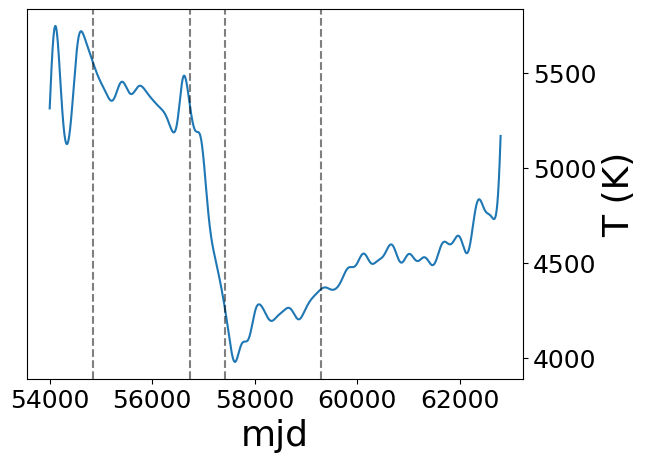

In [36]:
plt.plot(t, T, )

plt.xlabel('mjd')
plt.ylabel('T (K)')

ax = plt.gca()
# Move y-axis to the right
ax.yaxis.tick_right()                  # ticks on the right
ax.yaxis.set_label_position("right")   # label on the right

plt.axvline(54850, color='k', ls='--', alpha=0.5)
plt.axvline(56740, color='k', ls='--', alpha=0.5)
plt.axvline(57430, color='k', ls='--', alpha=0.5)
plt.axvline(59300, color='k', ls='--', alpha=0.5)


### compare with other transients

In [37]:
pwd

'/Users/home/Documents/EtaCarEchoes/old_vers1'

In [38]:


modelname = '../data/other_transients/gpmodels_for_publication/lrn_gmodel.pickle'
with open(modelname,'rb') as f:
    lrn_gmodel = pickle.load(f)

modelname = '../data/other_transients/gpmodels_for_publication/lrn_rmodel.pickle'
with open(modelname,'rb') as f:
    lrn_rmodel = pickle.load(f)

modelname = '../data/other_transients/gpmodels_for_publication/ilrt_gmodel.pickle'
with open(modelname,'rb') as f:
    ilrt_gmodel = pickle.load(f)

modelname = '../data/other_transients/gpmodels_for_publication/ilrt_rmodel.pickle'
with open(modelname,'rb') as f:
    ilrt_rmodel = pickle.load(f)


/Users/home/miniconda3/envs/sklearn-env/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator GaussianProcessRegressor from version 0.23.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Text(0.5, 1.0, 'Luminous Red Novae model')

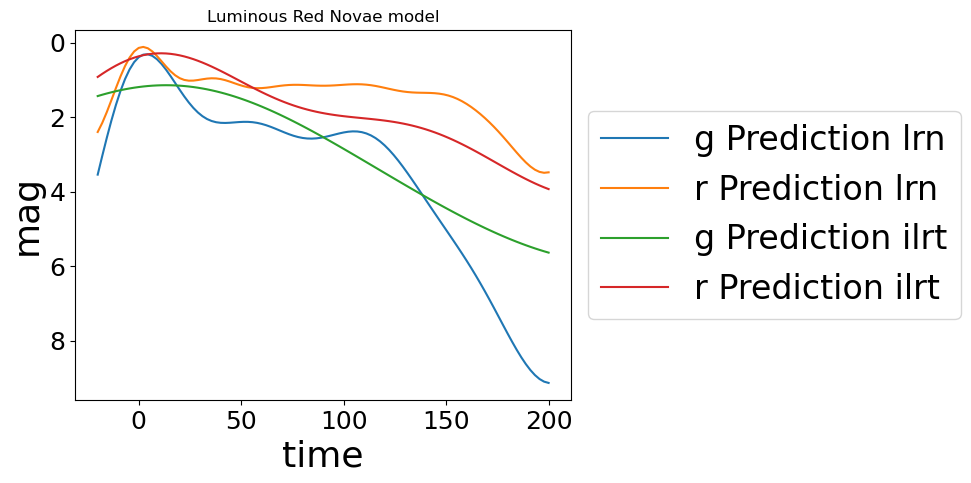

In [39]:
x = np.atleast_2d(np.linspace(-20,200,100)).T

y_pred_g_lrn, sigma_g_lrn = lrn_gmodel.predict(x, return_std=True)

y_pred_r_lrn, sigma_r_lrn = lrn_rmodel.predict(x, return_std=True)


y_pred_g_ilrt, sigma_g_ilrt = ilrt_gmodel.predict(x, return_std=True)

y_pred_r_ilrt, sigma_r_ilrt = ilrt_rmodel.predict(x, return_std=True)


plt.plot(x, y_pred_g_lrn, c=plt.cm.tab10(0), label='g Prediction lrn')
plt.plot(x, y_pred_r_lrn, c=plt.cm.tab10(1), label='r Prediction lrn')

plt.plot(x, y_pred_g_ilrt, c=plt.cm.tab10(2), label='g Prediction ilrt')
plt.plot(x, y_pred_r_ilrt, c=plt.cm.tab10(3), label='r Prediction ilrt')


plt.gca().invert_yaxis()

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.xlabel('time')
plt.ylabel('mag')

plt.title('Luminous Red Novae model')

### UGC2773_unfiltered

In [251]:
lc_ugc = pd.read_csv('../data/other_transients/UGC2773_unfiltered.csv', sep=r'\s+')

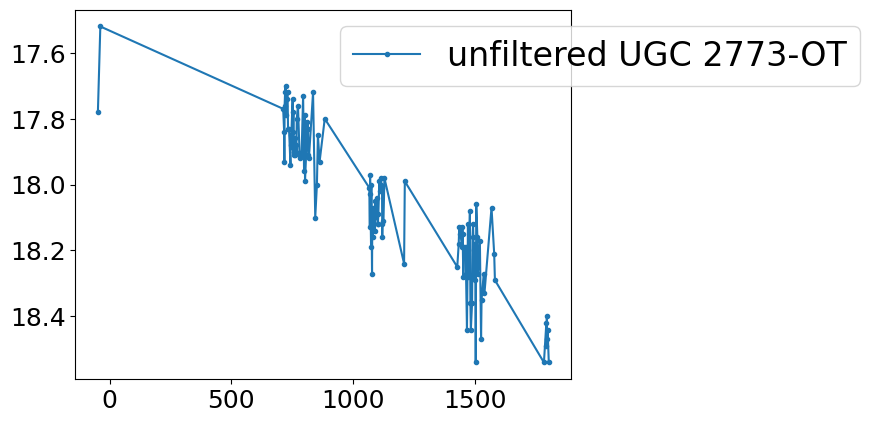

In [252]:
t_ugc = lc_ugc['MJD'].values - 55100
mag_ugc = lc_ugc['mag'].values

plt.plot(t_ugc, mag_ugc, '.-', label='unfiltered UGC 2773-OT')

plt.gca().invert_yaxis()
plt.legend(loc='upper left', bbox_to_anchor=(0.5, 1))

(-1000.0, 2000.0)

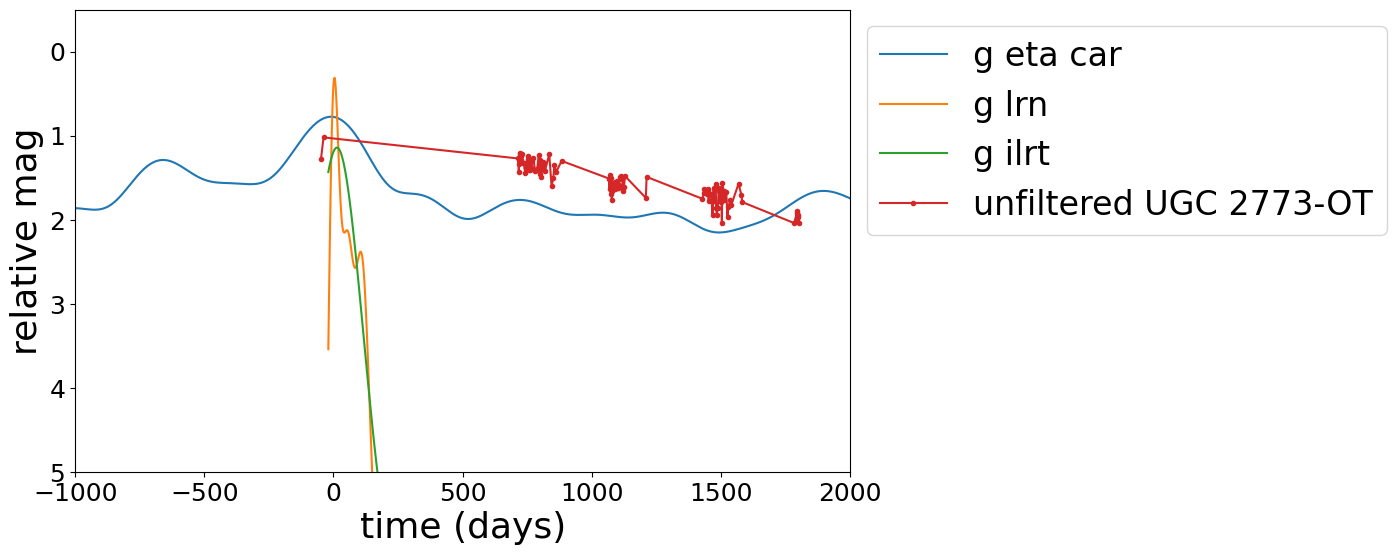

In [253]:
plt.figure(figsize=(10, 6))

plt.plot(t_ran-57400, g_new-20.5, label='g eta car')

plt.plot(x, y_pred_g_lrn, label='g lrn')

plt.plot(x, y_pred_g_ilrt, label='g ilrt')

plt.plot(t_ugc, mag_ugc-16.5, '.-', label='unfiltered UGC 2773-OT')


#plt.plot(x_09ip, sn2009ip_B-14, '.-', label='B SN2009ip')

plt.ylim([-.5, 5])
plt.gca().invert_yaxis()

plt.xlabel('time (days)')
plt.ylabel('relative mag')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.xlim([-1000, 2000])



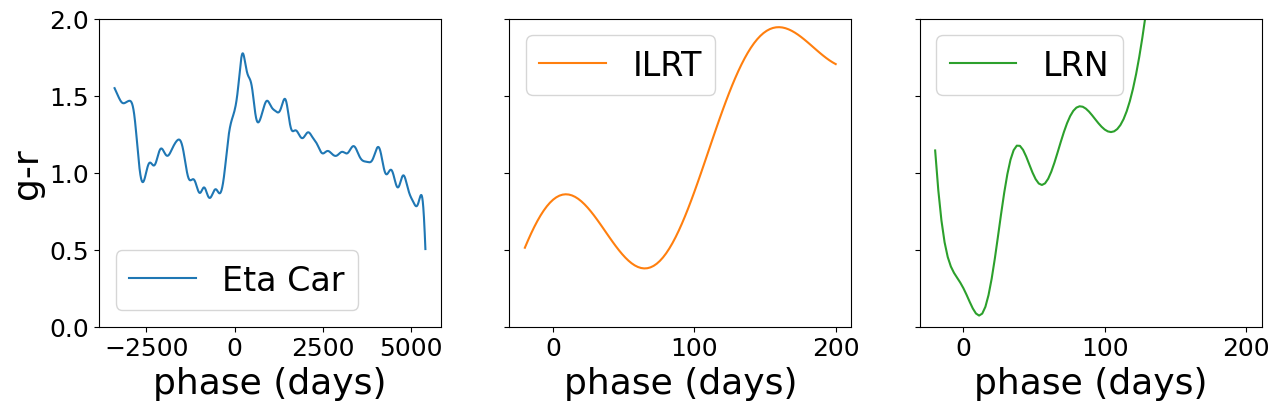

In [254]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

ax = axs[0]
ax.plot(t_ran-57400, g_new-r_new, label='Eta Car', c=plt.matplotlib.cm.tab10(0))
ax.set_ylim([0, 2])
ax.set_ylabel('g-r')
ax.set_xlabel('phase (days)')
ax.legend()

ax = axs[1]
ax.plot(x, y_pred_g_ilrt-y_pred_r_ilrt, label='ILRT', c=plt.matplotlib.cm.tab10(1))
ax.set_xlabel('phase (days)')
ax.legend()


ax = axs[2]
ax.plot(x, y_pred_g_lrn-y_pred_r_lrn, label='LRN', c=plt.matplotlib.cm.tab10(2))
ax.set_xlabel('phase (days)')
ax.legend()

#ax = axs[3]
#ax.plot(x_09ip, sn2009ip_B-sn2009ip_R, label='SN2009ip B-R', c=plt.matplotlib.cm.tab10(2))
#ax.set_xlabel('phase (days)')
#ax.legend()

